<a href="https://colab.research.google.com/github/Arpit-Prasad-01/Bootcamp-Projects/blob/main/Bootcamp_7%2C8%269_Session.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Linear Algebra (Vector Space Model & Cosine Similarity) and  Educational Data Mining (EDM) & Learning Analytics

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#study hours, attendance, previous_marks
students_a = np.array([65,78])
students_b = np.array([37,55])

print("Student A vector:", students_a)
print("Student B vector:", students_b)

Student A vector: [65 78]
Student B vector: [37 55]


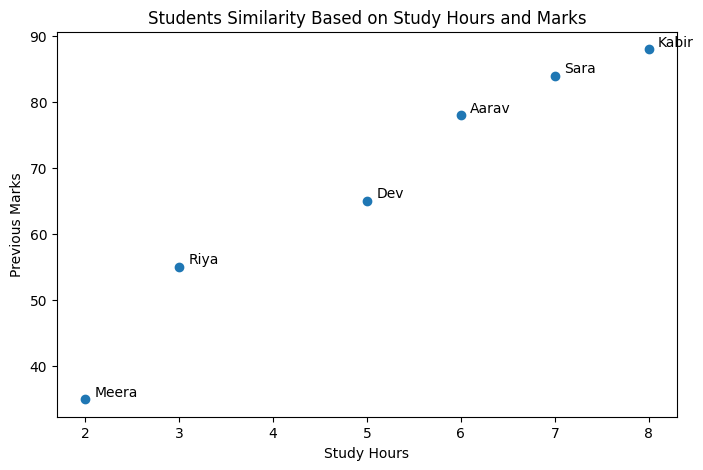

In [ ]:
students = pd.DataFrame({
    "name": ["Aarav", "Riya", "Kabir", "Meera", "Dev", "Sara"],
    "study_hours": [6, 3, 8, 2, 5, 7],
    "attendance": [85, 70, 90, 60, 78, 92],
    "previous_marks": [78, 55, 88, 35, 65, 84],
    "final_marks": [82, 58, 91, 40, 70, 88]
})



import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    students["study_hours"],
    students["previous_marks"]
)

for i, row in students.iterrows():
    plt.text(
        row["study_hours"] + 0.1,
        row["previous_marks"] + 0.5,
        row["name"]
    )

plt.xlabel("Study Hours")
plt.ylabel("Previous Marks")
plt.title("Students Similarity Based on Study Hours and Marks")

plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
students = pd.DataFrame({
    "name": ["Aarav", "Riya", "Kabir", "Meera", "Dev", "Sara"],
    "study_hours": [6, 3, 8, 2, 5, 7],
    "attendance": [85, 70, 90, 60, 78, 92],
    "previous_marks": [78, 55, 88, 35, 65, 84],
    "final_marks": [82, 58, 91, 40, 70, 88]
})

feature_columns = ["study_hours", "attendance", "previous_marks"]
student_vectors = students[feature_columns].values
print(student_vectors)




[[ 6 85 78]
 [ 3 70 55]
 [ 8 90 88]
 [ 2 60 35]
 [ 5 78 65]
 [ 7 92 84]]


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(student_vectors)

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=students["name"],
    columns=students["name"]
)

similarity_df

name,Aarav,Riya,Kabir,Meera,Dev,Sara
name,,,,,,
Aarav,1.000000,0.996913,0.999434,0.976875,0.998860,0.999988
Riya,0.996913,1.000000,0.993724,0.990505,0.999467,0.997017
Kabir,0.999434,0.993724,1.000000,0.969344,0.996756,0.999391
Meera,0.976875,0.990505,0.969344,1.000000,0.985958,0.977304
Dev,0.998860,0.999467,0.996756,0.985958,1.000000,0.998956
Sara,0.999988,0.997017,0.999391,0.977304,0.998956,1.000000


In [ ]:

dev_exact_name = [name for name in similarity_df.index if name.lower() == "dev"][0]
dev_scores = similarity_df[dev_exact_name].drop(index=dev_exact_name)

# 3. Get the closest student
closest_student = dev_scores.idxmax()
highest_score = dev_scores.max()

print(f"The student closest to {dev_exact_name} is: {closest_student}")
print(f"Similarity score: {highest_score:.4f}")


The student closest to Dev is: Riya
Similarity score: 0.9995


In [ ]:
aarav_scores = similarity_df["Aarav"].drop(index="Aarav")

# 2.closest student name and score
closest_student = aarav_scores.idxmax()
highest_score = aarav_scores.max()

print(f"The student closest to Aarav is: {closest_student}")
print(f"Similarity score: {highest_score:.4f}")


The student closest to Aarav is: Sara
Similarity score: 1.0000


In [ ]:
sentence = "this movie was not good"

tokens = sentence.lower().split(" ")

print(tokens)

['this', 'movie', 'was', 'not', 'good']


In [ ]:
vocab = {
    "this": 1,
    "movie": 2,
    "was": 3,
    "not": 4,
    "good": 5
}

token_ids = [vocab[word] for word in tokens]

print(token_ids)

[1, 2, 3, 4, 5]


In [ ]:
sentences = [
    "dog bites man",
    "man bites dog",
    "the movie was good",
    "the movie was not good"
]

for sentence in sentences:
    print(sentence, "->", sentence.split())

dog bites man -> ['dog', 'bites', 'man']
man bites dog -> ['man', 'bites', 'dog']
the movie was good -> ['the', 'movie', 'was', 'good']
the movie was not good -> ['the', 'movie', 'was', 'not', 'good']


In [3]:
positive_words = ["good", "great", "amazing", "excellent", "love"]
negative_words = ["bad", "terrible", "poor", "hate", "boring"]

def simple_sentiment(sentence):
    words = sentence.lower().replace(".", "").split()

    score = 0

    for word in words:
        if word in positive_words:
            score += 1
        elif word in negative_words:
            score -= 1

    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

print(simple_sentiment("The movie was good"))
print(simple_sentiment("The movie was bad"))
print(simple_sentiment("The movie was not good"))


Positive
Negative
Positive


In [5]:
sentence = "the movie was not good"
tokens = sentence.split()

memory = ""

for token in tokens:
    memory = memory + " " + token
    print("Current token:", token)
    print("memory so far:", memory.strip())

Current token: the
memory so far: the
Current token: movie
memory so far: the movie
Current token: was
memory so far: the movie was
Current token: not
memory so far: the movie was not
Current token: good
memory so far: the movie was not good


In [4]:
sentence = "the movie was not good"
tokens = sentence.split()

hidden_state = {
    "topic": None,
    "negation_active": False,
    "sentiment_word": None
}

for token in tokens:
    if token in ["movie", "food", "product"]:
        hidden_state["topic"] = token

    if token == "not":
        hidden_state["negation_active"] = True

    if token in ["good", "bad", "great", "terrible"]:
        hidden_state["sentiment_word"] = token

    print("Token:", token)
    print("Hidden state:", hidden_state)
    print("-----")

Token: the
Hidden state: {'topic': None, 'negation_active': False, 'sentiment_word': None}
-----
Token: movie
Hidden state: {'topic': 'movie', 'negation_active': False, 'sentiment_word': None}
-----
Token: was
Hidden state: {'topic': 'movie', 'negation_active': False, 'sentiment_word': None}
-----
Token: not
Hidden state: {'topic': 'movie', 'negation_active': True, 'sentiment_word': None}
-----
Token: good
Hidden state: {'topic': 'movie', 'negation_active': True, 'sentiment_word': 'good'}
-----


In [6]:
import tensorflow as tf
from tensorflow.keras import layers

vocab_size = 1000
embedding_dim = 16
sequence_length = 8

simple_rnn_model = tf.keras.Sequential([
    layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=sequence_length),
    layers.SimpleRNN(32),
    layers.Dense(1, activation='sigmoid')
    #0-1
])

simple_rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)